# 01C · Data Preprocessing (All four C-MAPSS datasets)
**C-MAPSS Turbofan Engine Degradation — FD001, FD002, FD003 & FD004**

> Covers raw loading → EDA → feature selection → RUL labelling → normalisation → synthetic augmentation (where applicable) → sliding-window sequence creation → train / validation / test split → artefact saving.

---
## Section 1 · Project Setup

In [ ]:
import sys
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    print('Drive mounted.')
else:
    print('Running locally — Drive mount skipped.')

Mounted at /content/drive
Drive mounted.


In [ ]:
# !pip install -q pandas numpy matplotlib seaborn scikit-learn

In [ ]:
import os, json, pickle, warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
print('All packages imported.')

All packages imported.


In [ ]:
if IN_COLAB:
    BASE_DATA_DIR = '/content/drive/MyDrive/CMAPSSData'
else:
    BASE_DATA_DIR = './data/CMAPSSData'

OUTPUT_DIR = './outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

DATASETS = ['FD001', 'FD002', 'FD003', 'FD004']

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
print(f'Datasets : {DATASETS}')
print(f'Data dir : {os.path.abspath(BASE_DATA_DIR)}')
print(f'Output dir: {os.path.abspath(OUTPUT_DIR)}')

Datasets : ['FD001', 'FD002', 'FD003', 'FD004']
Data dir : /content/drive/MyDrive/CMAPSSData
Output dir: /content/outputs


---
## Section 2 · Dataset Description

This notebook uses all four C-MAPSS sub-datasets:

| Dataset | Operating conditions | Fault modes | Train engines |
|---------|---------------------|-------------|---------------|
| FD001 | 1 | HPC degradation | 100 |
| FD002 | 6 | HPC degradation | 260 |
| FD003 | 1 | HPC + fan degradation | 100 |
| FD004 | 6 | HPC + fan degradation | 249 |

Combining all four datasets exposes the model to both single and multi-condition operating regimes and both single and dual fault modes, providing the broadest possible training distribution. Engine IDs are kept separate per dataset (no global re-indexing needed since the model treats them independently via the per-engine split logic).

---
## Section 3 · Load Raw Files

Each dataset is loaded independently. `unit_nr` values are **offset** per dataset before merging so engine IDs remain unique across the combined dataframe.

In [ ]:
SENSOR_COLS     = [f'sensor_{i}' for i in range(1, 22)]
OP_SETTING_COLS = ['op_setting_1', 'op_setting_2', 'op_setting_3']
BASE_COLS       = ['unit_nr', 'time_cycles'] + OP_SETTING_COLS + SENSOR_COLS
print(f'Total columns: {len(BASE_COLS)}')

Total columns: 26


In [ ]:
def load_cmapss(filepath, col_names):
    df = pd.read_csv(filepath, delim_whitespace=True, header=None, engine='python')
    df.dropna(axis=1, how='all', inplace=True)
    df.columns = col_names[:df.shape[1]]
    return df

raw = {}
for ds in DATASETS:
    train_path = os.path.join(BASE_DATA_DIR, f'train_{ds}.txt')
    test_path  = os.path.join(BASE_DATA_DIR, f'test_{ds}.txt')
    rul_path   = os.path.join(BASE_DATA_DIR, f'RUL_{ds}.txt')
    df_train = load_cmapss(train_path, BASE_COLS)
    df_test  = load_cmapss(test_path,  BASE_COLS)
    df_rul   = pd.read_csv(rul_path, header=None, names=['rul_true'])
    raw[ds]  = {'train': df_train, 'test': df_test, 'rul': df_rul}
    print(f'[{ds}]  train: {df_train.shape}  test: {df_test.shape}')

[FD001]  train: (20631, 26)  test: (13096, 26)
[FD002]  train: (53759, 26)  test: (33991, 26)
[FD003]  train: (24720, 26)  test: (16596, 26)
[FD004]  train: (61249, 26)  test: (41214, 26)


---
## Section 4 · Initial EDA

In [ ]:
for ds in DATASETS:
    df = raw[ds]['train']
    lives = df.groupby('unit_nr')['time_cycles'].max()
    print(f'[{ds}]  shape={df.shape}  engines={df["unit_nr"].nunique()}  '
          f'min_life={lives.min()}  max_life={lives.max()}  '
          f'nulls={df.isnull().sum().sum()}  dups={df.duplicated().sum()}')

[FD001]  shape=(20631, 26)  engines=100  min_life=128  max_life=362  nulls=0  dups=0
[FD002]  shape=(53759, 26)  engines=260  min_life=128  max_life=378  nulls=0  dups=0
[FD003]  shape=(24720, 26)  engines=100  min_life=145  max_life=525  nulls=0  dups=0
[FD004]  shape=(61249, 26)  engines=249  min_life=128  max_life=543  nulls=0  dups=0


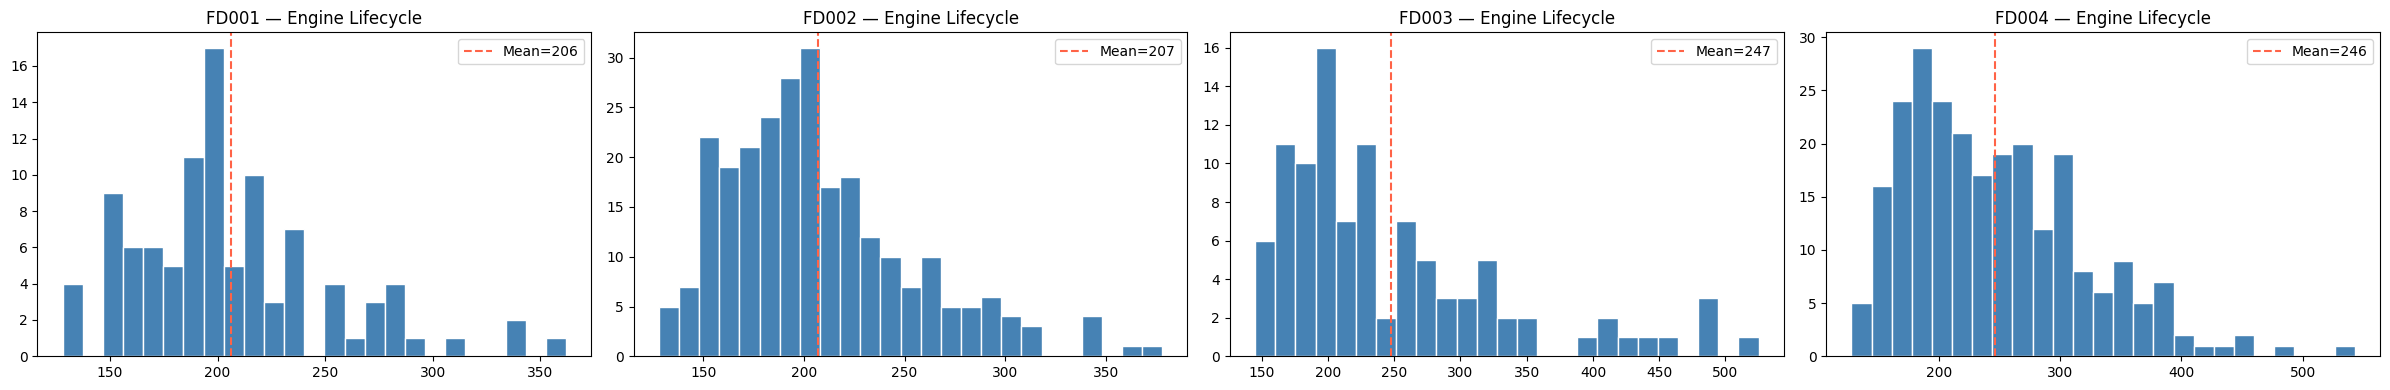

In [ ]:
fig, axes = plt.subplots(1, len(DATASETS), figsize=(6*len(DATASETS), 4))
if len(DATASETS) == 1: axes = [axes]
for ax, ds in zip(axes, DATASETS):
    lives = raw[ds]['train'].groupby('unit_nr')['time_cycles'].max()
    ax.hist(lives, bins=25, color='steelblue', edgecolor='white')
    ax.axvline(lives.mean(), color='tomato', linestyle='--', label=f'Mean={lives.mean():.0f}')
    ax.set_title(f'{ds} — Engine Lifecycle'); ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'eda_lifecycle.png'), dpi=120); plt.show()

---
## Section 5 · Feature Selection

> **Initial feature set retained from C-MAPSS, with optional pruning of low-information sensors after exploratory analysis.**

Sensors with `std < 0.001` are removed as near-constant features. For multi-dataset runs the feature set is derived from the **combined** training data so that all datasets share an identical feature space.

In [ ]:
CANDIDATE_FEATURES = ['time_cycles'] + OP_SETTING_COLS + SENSOR_COLS
VARIANCE_THRESHOLD = 1e-3

# Compute std over the union of all training data
all_train = pd.concat([raw[ds]['train'] for ds in DATASETS], ignore_index=True)
stds      = all_train[CANDIDATE_FEATURES].std()
dropped   = stds[stds < VARIANCE_THRESHOLD].index.tolist()
FEATURES  = [f for f in CANDIDATE_FEATURES if f not in dropped]

# Same feature list applied to all datasets
selected_features = {ds: FEATURES for ds in DATASETS}

print(f'Dropped  ({len(dropped)}): {dropped}')
print(f'Retained ({len(FEATURES)}): {FEATURES}')

Dropped  (0): []
Retained (25): ['time_cycles', 'op_setting_1', 'op_setting_2', 'op_setting_3', 'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21']


---
## Section 6 · RUL Labelling

Piecewise-capped RUL: $\\text{RUL} = \\min(\\text{max\_cycle} - \\text{cycle},\; 125)$

In [ ]:
RUL_CAP = 125

def add_rul_column(df, cap=RUL_CAP):
    df = df.copy()
    max_cycles = df.groupby('unit_nr')['time_cycles'].max().rename('max_cycle')
    df = df.join(max_cycles, on='unit_nr')
    df['RUL'] = (df['max_cycle'] - df['time_cycles']).clip(upper=cap)
    df.drop(columns=['max_cycle'], inplace=True)
    return df

for ds in DATASETS:
    raw[ds]['train'] = add_rul_column(raw[ds]['train'])
    r = raw[ds]['train']['RUL']
    print(f'[{ds}] RUL range: {r.min()} – {r.max()}')

[FD001] RUL range: 0 – 125
[FD002] RUL range: 0 – 125
[FD003] RUL range: 0 – 125
[FD004] RUL range: 0 – 125


---
## Section 7 · Prepare Test Labels

In [ ]:
for ds in DATASETS:
    df_test  = raw[ds]['test'].copy()
    df_rul   = raw[ds]['rul'].copy()
    df_rul.index = df_rul.index + 1
    df_rul.index.name = 'unit_nr'
    last_idx  = df_test.groupby('unit_nr')['time_cycles'].idxmax()
    df_last   = df_test.loc[last_idx].copy().reset_index(drop=True)
    df_last['rul_true'] = df_rul['rul_true'].values
    df_last['rul_true'] = df_last['rul_true'].clip(upper=RUL_CAP)
    raw[ds]['test_last'] = df_last
    print(f'[{ds}] test engines: {len(df_last)}, RUL range: {df_last["rul_true"].min()}–{df_last["rul_true"].max()}')

[FD001] test engines: 100, RUL range: 7–125
[FD002] test engines: 259, RUL range: 6–125
[FD003] test engines: 100, RUL range: 6–125
[FD004] test engines: 248, RUL range: 6–125


---
## Section 8 · Normalisation / Scaling

`StandardScaler` fitted on training data only; saved with pickle.

In [ ]:
scalers = {}
for ds in DATASETS:
    feats       = selected_features[ds]
    train_feats = raw[ds]['train'][feats].values
    scaler      = StandardScaler().fit(train_feats)
    scalers[ds] = scaler
    with open(os.path.join(OUTPUT_DIR, f'scaler_{ds}.pkl'), 'wb') as f:
        pickle.dump(scaler, f)
    print(f'[{ds}] Scaler fitted — shape {train_feats.shape}')

[FD001] Scaler fitted — shape (20631, 25)
[FD002] Scaler fitted — shape (53759, 25)
[FD003] Scaler fitted — shape (24720, 25)
[FD004] Scaler fitted — shape (61249, 25)


---
## Section 9 · Sliding Window Sequence Creation

Window size = 50, stride = 1. Target = RUL at last cycle of each window.

In [ ]:
WINDOW_SIZE = 50
STRIDE      = 1

def make_windows(df, feature_cols, scaler, window_size=WINDOW_SIZE,
                 stride=STRIDE, rul_col='RUL'):
    X_list, y_list, uid_list = [], [], []
    for uid, grp in df.groupby('unit_nr'):
        grp   = grp.sort_values('time_cycles')
        feats = scaler.transform(grp[feature_cols].values)
        rul   = grp[rul_col].values
        if len(feats) < window_size:
            continue
        for start in range(0, len(feats) - window_size + 1, stride):
            end = start + window_size
            X_list.append(feats[start:end])
            y_list.append(rul[end - 1])
            uid_list.append(uid)
    return (np.array(X_list, dtype=np.float32),
            np.array(y_list,  dtype=np.float32),
            np.array(uid_list, dtype=np.int32))

def make_test_windows(df_full, df_last, feature_cols, scaler, window_size=WINDOW_SIZE):
    X_list, y_list, uid_list = [], [], []
    for _, row in df_last.iterrows():
        uid  = int(row['unit_nr'])
        grp  = df_full[df_full['unit_nr'] == uid].sort_values('time_cycles')
        feats = scaler.transform(grp[feature_cols].values)
        if len(feats) < window_size:
            continue
        X_list.append(feats[-window_size:])
        y_list.append(row['rul_true'])
        uid_list.append(uid)
    return (np.array(X_list, dtype=np.float32),
            np.array(y_list,  dtype=np.float32),
            np.array(uid_list, dtype=np.int32))

print('Window functions defined.')

Window functions defined.


---
## Section 10 · Train / Validation / Hold-out Split

Split is performed **by engine id** (70 / 15 / 15) before windowing to prevent temporal data leakage between splits.

In [ ]:
TRAIN_FRAC = 0.70
VAL_FRAC   = 0.15

datasets_processed = {}

for ds in DATASETS:
    feats   = selected_features[ds]
    scaler  = scalers[ds]
    df_tr   = raw[ds]['train']
    df_te   = raw[ds]['test']
    df_last = raw[ds]['test_last']

    engine_ids = df_tr['unit_nr'].unique()
    np.random.shuffle(engine_ids)
    n_train = int(np.floor(TRAIN_FRAC * len(engine_ids)))
    n_val   = int(np.floor(VAL_FRAC   * len(engine_ids)))
    train_ids = engine_ids[:n_train]
    val_ids   = engine_ids[n_train:n_train+n_val]
    hold_ids  = engine_ids[n_train+n_val:]

    X_tr, y_tr, ids_tr = make_windows(df_tr[df_tr['unit_nr'].isin(train_ids)], feats, scaler)
    X_vl, y_vl, ids_vl = make_windows(df_tr[df_tr['unit_nr'].isin(val_ids)],   feats, scaler)
    X_ho, y_ho, ids_ho = make_windows(df_tr[df_tr['unit_nr'].isin(hold_ids)],  feats, scaler)
    X_te, y_te, ids_te = make_test_windows(df_te, df_last, feats, scaler)

    datasets_processed[ds] = dict(
        X_train=X_tr, y_train=y_tr, ids_train=ids_tr,
        X_val=X_vl,   y_val=y_vl,   ids_val=ids_vl,
        X_hold=X_ho,  y_hold=y_ho,  ids_hold=ids_ho,
        X_test=X_te,  y_test=y_te,  ids_test=ids_te,
        features=feats
    )
    print(f'[{ds}]  train={X_tr.shape}  val={X_vl.shape}  hold={X_ho.shape}  test={X_te.shape}')

[FD001]  train=(10886, 50, 25)  val=(2435, 50, 25)  hold=(2410, 50, 25)  test=(93, 50, 25)
[FD002]  train=(29123, 50, 25)  val=(5850, 50, 25)  hold=(6046, 50, 25)  test=(235, 50, 25)
[FD003]  train=(14222, 50, 25)  val=(2475, 50, 25)  hold=(3123, 50, 25)  test=(97, 50, 25)
[FD004]  train=(34604, 50, 25)  val=(7100, 50, 25)  hold=(7344, 50, 25)  test=(228, 50, 25)


---
## Section 11 · Save Processed Artefacts

In [ ]:
for ds in DATASETS:
    d = datasets_processed[ds]
    np.savez_compressed(
        os.path.join(OUTPUT_DIR, f'{ds}_01C_processed.npz'),
        X_train=d['X_train'], y_train=d['y_train'], ids_train=d['ids_train'],
        X_val  =d['X_val'],   y_val  =d['y_val'],   ids_val  =d['ids_val'],
        X_hold =d['X_hold'],  y_hold =d['y_hold'],  ids_hold =d['ids_hold'],
        X_test =d['X_test'],  y_test =d['y_test'],  ids_test =d['ids_test'],
    )
    print(f'[{ds}] Saved')

with open(os.path.join(OUTPUT_DIR, 'selected_features_01C.json'), 'w') as f:
    json.dump(selected_features, f, indent=2)

meta = dict(window_size=WINDOW_SIZE, stride=STRIDE, rul_cap=RUL_CAP,
            train_frac=TRAIN_FRAC, val_frac=VAL_FRAC,
            random_seed=RANDOM_SEED, scaler_type='StandardScaler',
            datasets=DATASETS, variant='FD001+FD002+FD003+FD004')
with open(os.path.join(OUTPUT_DIR, 'preprocessing_metadata_01C.json'), 'w') as f:
    json.dump(meta, f, indent=2)
print('All artefacts saved.')

[FD001] Saved
[FD002] Saved
[FD003] Saved
[FD004] Saved
All artefacts saved.


---
## Section 12 · Final Sanity Checks

In [ ]:
print('='*60)
for ds in DATASETS:
    d = datasets_processed[ds]
    for split in ('train', 'val', 'hold', 'test'):
        X = d[f'X_{split}']; y = d[f'y_{split}']
        print(f'  [{ds}] {split:>5}  X={str(X.shape):>22}  y={str(y.shape):>10}  RUL=[{y.min():.0f},{y.max():.0f}]')
print('='*60)
print('\n✅  Preprocessing complete. Artefacts in:', os.path.abspath(OUTPUT_DIR))

  [FD001] train  X=       (10886, 50, 25)  y=  (10886,)  RUL=[0,125]
  [FD001]   val  X=        (2435, 50, 25)  y=   (2435,)  RUL=[0,125]
  [FD001]  hold  X=        (2410, 50, 25)  y=   (2410,)  RUL=[0,125]
  [FD001]  test  X=          (93, 50, 25)  y=     (93,)  RUL=[7,125]
  [FD002] train  X=       (29123, 50, 25)  y=  (29123,)  RUL=[0,125]
  [FD002]   val  X=        (5850, 50, 25)  y=   (5850,)  RUL=[0,125]
  [FD002]  hold  X=        (6046, 50, 25)  y=   (6046,)  RUL=[0,125]
  [FD002]  test  X=         (235, 50, 25)  y=    (235,)  RUL=[6,125]
  [FD003] train  X=       (14222, 50, 25)  y=  (14222,)  RUL=[0,125]
  [FD003]   val  X=        (2475, 50, 25)  y=   (2475,)  RUL=[0,125]
  [FD003]  hold  X=        (3123, 50, 25)  y=   (3123,)  RUL=[0,125]
  [FD003]  test  X=          (97, 50, 25)  y=     (97,)  RUL=[6,125]
  [FD004] train  X=       (34604, 50, 25)  y=  (34604,)  RUL=[0,125]
  [FD004]   val  X=        (7100, 50, 25)  y=   (7100,)  RUL=[0,125]
  [FD004]  hold  X=        (7344, 

In [ ]:
# Colab download helper
try:
    import shutil
    from google.colab import files
    shutil.make_archive('outputs', 'zip', OUTPUT_DIR)
    files.download('outputs.zip')
except:
    print('Not in Colab or download not needed.')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>